In [7]:
# 1셀. 라이브러리 및 경로 설정
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from scipy.stats import mannwhitneyu

# 프로젝트 루트 경로
PROJECT_DIR = Path(r"C:\취준\mobile-game-retention-review-ua-analysis")

# 폴더 경로
RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_TABLE_DIR = PROJECT_DIR / "outputs" / "tables"
OUTPUT_FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
DOCS_DIR = PROJECT_DIR / "docs"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"

# 폴더 생성
for path in [RAW_DIR, PROCESSED_DIR, OUTPUT_TABLE_DIR, OUTPUT_FIGURE_DIR, DOCS_DIR, NOTEBOOK_DIR]:
    path.mkdir(parents=True, exist_ok=True)

# 데이터 경로
DATA_PATH = RAW_DIR / "cookie_cats.csv"

print("Project directory:", PROJECT_DIR)
print("Data path exists:", DATA_PATH.exists())

Project directory: C:\취준\mobile-game-retention-review-ua-analysis
Data path exists: True


In [8]:
# 2셀. 데이터 로드 및 기본 확인
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include="all"))

Shape: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.8 MB


None

,userid,version,sum_gamerounds,retention_1,retention_7
count,9.018900e+04,90189,90189.000000,90189,90189
unique,NaN,2,NaN,2,2
top,NaN,gate_40,NaN,False,False
freq,NaN,45489,NaN,50036,73408
mean,4.998412e+06,NaN,51.872457,NaN,NaN
std,2.883286e+06,NaN,195.050858,NaN,NaN
min,1.160000e+02,NaN,0.000000,NaN,NaN
25%,2.512230e+06,NaN,5.000000,NaN,NaN
50%,4.995815e+06,NaN,16.000000,NaN,NaN
75%,7.496452e+06,NaN,51.000000,NaN,NaN


In [9]:
# 3셀. 데이터 품질 점검
quality_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [df[col].dtype for col in df.columns],
    "missing_count": [df[col].isna().sum() for col in df.columns],
    "missing_rate": [df[col].isna().mean() for col in df.columns],
    "unique_count": [df[col].nunique() for col in df.columns],
})

display(quality_summary)

print("Duplicated userid count:", df["userid"].duplicated().sum())
print("Version values:", df["version"].unique())
print("Retention_1 values:", df["retention_1"].unique())
print("Retention_7 values:", df["retention_7"].unique())

quality_summary.to_csv(
    OUTPUT_TABLE_DIR / "cookie_cats_data_quality_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

,column,dtype,missing_count,missing_rate,unique_count
0,userid,int64,0,0.0,90189
1,version,str,0,0.0,2
2,sum_gamerounds,int64,0,0.0,942
3,retention_1,bool,0,0.0,2
4,retention_7,bool,0,0.0,2


Duplicated userid count: 0
Version values: <ArrowStringArray>
['gate_30', 'gate_40']
Length: 2, dtype: str
Retention_1 values: [False  True]
Retention_7 values: [False  True]


In [10]:
# 4셀. Boolean 컬럼 정리
df["retention_1"] = df["retention_1"].astype(bool)
df["retention_7"] = df["retention_7"].astype(bool)

# 분석용 저장
df.to_csv(
    PROCESSED_DIR / "cookie_cats_cleaned.csv",
    index=False,
    encoding="utf-8-sig"
)

display(df.head())

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [11]:
# 5셀. 그룹별 기본 요약
group_summary = (
    df.groupby("version")
    .agg(
        users=("userid", "count"),
        avg_gamerounds=("sum_gamerounds", "mean"),
        median_gamerounds=("sum_gamerounds", "median"),
        std_gamerounds=("sum_gamerounds", "std"),
        d1_retention=("retention_1", "mean"),
        d7_retention=("retention_7", "mean"),
    )
    .reset_index()
)

group_summary["d1_retention_pct"] = group_summary["d1_retention"] * 100
group_summary["d7_retention_pct"] = group_summary["d7_retention"] * 100

display(group_summary)

group_summary.to_csv(
    OUTPUT_TABLE_DIR / "cookie_cats_group_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

,version,users,avg_gamerounds,median_gamerounds,std_gamerounds,d1_retention,d7_retention,d1_retention_pct,d7_retention_pct
0,gate_30,44700,52.456264,17.0,256.716423,0.448188,0.190201,44.818792,19.020134
1,gate_40,45489,51.298776,16.0,103.294416,0.442283,0.182000,44.228275,18.200004


In [12]:
# 6셀. Retention 차이 계산
gate30 = df[df["version"] == "gate_30"]
gate40 = df[df["version"] == "gate_40"]

retention_diff = pd.DataFrame({
    "metric": ["D1 Retention", "D7 Retention"],
    "gate_30": [
        gate30["retention_1"].mean(),
        gate30["retention_7"].mean()
    ],
    "gate_40": [
        gate40["retention_1"].mean(),
        gate40["retention_7"].mean()
    ],
})

retention_diff["diff_gate40_minus_gate30"] = retention_diff["gate_40"] - retention_diff["gate_30"]
retention_diff["uplift_rate"] = retention_diff["diff_gate40_minus_gate30"] / retention_diff["gate_30"]

display(retention_diff)

retention_diff.to_csv(
    OUTPUT_TABLE_DIR / "cookie_cats_retention_diff.csv",
    index=False,
    encoding="utf-8-sig"
)

,metric,gate_30,gate_40,diff_gate40_minus_gate30,uplift_rate
0,D1 Retention,0.448188,0.442283,-0.005905,-0.013176
1,D7 Retention,0.190201,0.182000,-0.008201,-0.043119


In [13]:
# 7셀. 비율 z-test
def run_proportion_ztest(data, metric_col):
    summary = data.groupby("version")[metric_col].agg(["sum", "count"])
    
    # gate_30, gate_40 순서 고정
    count = np.array([
        summary.loc["gate_30", "sum"],
        summary.loc["gate_40", "sum"]
    ])
    nobs = np.array([
        summary.loc["gate_30", "count"],
        summary.loc["gate_40", "count"]
    ])
    
    stat, p_value = proportions_ztest(count=count, nobs=nobs)
    
    ci_low_30, ci_high_30 = proportion_confint(count[0], nobs[0], alpha=0.05, method="normal")
    ci_low_40, ci_high_40 = proportion_confint(count[1], nobs[1], alpha=0.05, method="normal")
    
    return {
        "metric": metric_col,
        "gate_30_success": count[0],
        "gate_30_users": nobs[0],
        "gate_30_rate": count[0] / nobs[0],
        "gate_30_ci_low": ci_low_30,
        "gate_30_ci_high": ci_high_30,
        "gate_40_success": count[1],
        "gate_40_users": nobs[1],
        "gate_40_rate": count[1] / nobs[1],
        "gate_40_ci_low": ci_low_40,
        "gate_40_ci_high": ci_high_40,
        "diff_gate40_minus_gate30": (count[1] / nobs[1]) - (count[0] / nobs[0]),
        "z_stat": stat,
        "p_value": p_value,
    }

ztest_results = pd.DataFrame([
    run_proportion_ztest(df, "retention_1"),
    run_proportion_ztest(df, "retention_7"),
])

display(ztest_results)

ztest_results.to_csv(
    OUTPUT_TABLE_DIR / "cookie_cats_proportion_ztest_results.csv",
    index=False,
    encoding="utf-8-sig"
)

,metric,gate_30_success,gate_30_users,gate_30_rate,gate_30_ci_low,gate_30_ci_high,gate_40_success,gate_40_users,gate_40_rate,gate_40_ci_low,gate_40_ci_high,diff_gate40_minus_gate30,z_stat,p_value
0,retention_1,20034,44700,0.448188,0.443578,0.452798,20119,45489,0.442283,0.437719,0.446847,-0.005905,1.784086,0.074410
1,retention_7,8502,44700,0.190201,0.186563,0.193840,8279,45489,0.182000,0.178454,0.185546,-0.008201,3.164359,0.001554


In [14]:
# 8셀. Bootstrap으로 retention 차이 신뢰구간 계산
def bootstrap_retention_diff(data, metric_col, n_bootstrap=5000, random_state=42):
    rng = np.random.default_rng(random_state)
    
    gate30_values = data.loc[data["version"] == "gate_30", metric_col].astype(int).to_numpy()
    gate40_values = data.loc[data["version"] == "gate_40", metric_col].astype(int).to_numpy()
    
    diffs = []
    for _ in range(n_bootstrap):
        sample30 = rng.choice(gate30_values, size=len(gate30_values), replace=True)
        sample40 = rng.choice(gate40_values, size=len(gate40_values), replace=True)
        diffs.append(sample40.mean() - sample30.mean())
    
    diffs = np.array(diffs)
    
    return {
        "metric": metric_col,
        "observed_diff_gate40_minus_gate30": gate40_values.mean() - gate30_values.mean(),
        "bootstrap_ci_low": np.percentile(diffs, 2.5),
        "bootstrap_ci_high": np.percentile(diffs, 97.5),
        "bootstrap_mean_diff": diffs.mean(),
    }

bootstrap_results = pd.DataFrame([
    bootstrap_retention_diff(df, "retention_1"),
    bootstrap_retention_diff(df, "retention_7"),
])

display(bootstrap_results)

bootstrap_results.to_csv(
    OUTPUT_TABLE_DIR / "cookie_cats_bootstrap_retention_diff.csv",
    index=False,
    encoding="utf-8-sig"
)

,metric,observed_diff_gate40_minus_gate30,bootstrap_ci_low,bootstrap_ci_high,bootstrap_mean_diff
0,retention_1,-0.005905,-0.012268,0.000544,-0.005879
1,retention_7,-0.008201,-0.013430,-0.003286,-0.008301


In [15]:
# 9셀. 게임 라운드 수 분포 및 검정
round_summary = (
    df.groupby("version")["sum_gamerounds"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

display(round_summary)

# sum_gamerounds는 치우친 분포일 가능성이 높으므로 Mann-Whitney U test 사용
u_stat, mw_p_value = mannwhitneyu(
    gate30["sum_gamerounds"],
    gate40["sum_gamerounds"],
    alternative="two-sided"
)

round_test_result = pd.DataFrame([{
    "metric": "sum_gamerounds",
    "test": "Mann-Whitney U",
    "u_stat": u_stat,
    "p_value": mw_p_value,
}])

display(round_test_result)

round_summary.to_csv(
    OUTPUT_TABLE_DIR / "cookie_cats_round_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

round_test_result.to_csv(
    OUTPUT_TABLE_DIR / "cookie_cats_round_test_result.csv",
    index=False,
    encoding="utf-8-sig"
)

,version,count,mean,median,std,min,max
0,gate_30,44700,52.456264,17.0,256.716423,0,49854
1,gate_40,45489,51.298776,16.0,103.294416,0,2640


,metric,test,u_stat,p_value
0,sum_gamerounds,Mann-Whitney U,1.024331e+09,0.050209


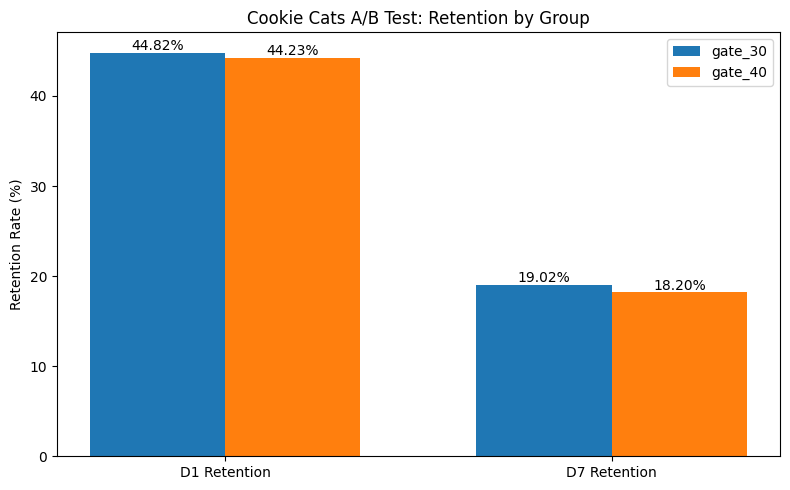

In [16]:
# 10셀. Retention 시각화
plot_data = retention_diff.copy()
plot_data["gate_30_pct"] = plot_data["gate_30"] * 100
plot_data["gate_40_pct"] = plot_data["gate_40"] * 100

x = np.arange(len(plot_data))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, plot_data["gate_30_pct"], width, label="gate_30")
ax.bar(x + width/2, plot_data["gate_40_pct"], width, label="gate_40")

ax.set_title("Cookie Cats A/B Test: Retention by Group")
ax.set_ylabel("Retention Rate (%)")
ax.set_xticks(x)
ax.set_xticklabels(plot_data["metric"])
ax.legend()

for i, row in plot_data.iterrows():
    ax.text(i - width/2, row["gate_30_pct"] + 0.3, f"{row['gate_30_pct']:.2f}%", ha="center")
    ax.text(i + width/2, row["gate_40_pct"] + 0.3, f"{row['gate_40_pct']:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "cookie_cats_retention_by_group.png", dpi=150)
plt.show()

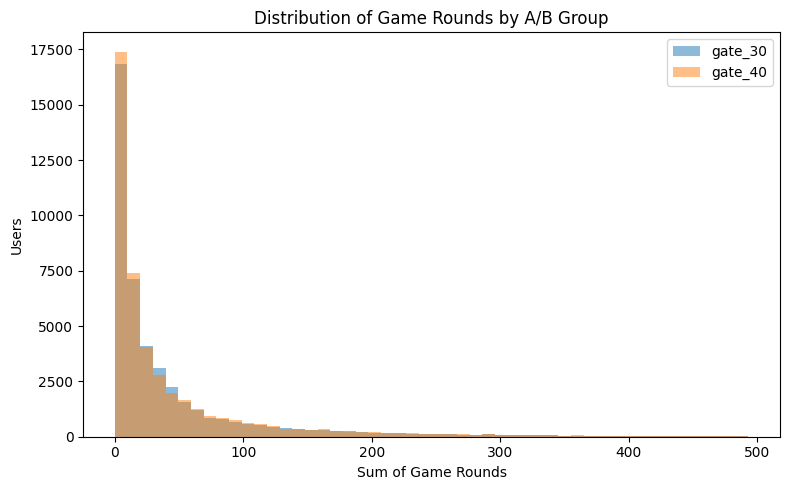

In [17]:
# 11셀. 게임 라운드 분포 시각화
# 극단값 때문에 99백분위 이하만 시각화
upper_limit = df["sum_gamerounds"].quantile(0.99)
plot_rounds = df[df["sum_gamerounds"] <= upper_limit]

fig, ax = plt.subplots(figsize=(8, 5))

for version in ["gate_30", "gate_40"]:
    subset = plot_rounds[plot_rounds["version"] == version]
    ax.hist(subset["sum_gamerounds"], bins=50, alpha=0.5, label=version)

ax.set_title("Distribution of Game Rounds by A/B Group")
ax.set_xlabel("Sum of Game Rounds")
ax.set_ylabel("Users")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_FIGURE_DIR / "cookie_cats_gamerounds_distribution.png", dpi=150)
plt.show()

In [18]:
# 12셀. 최종 인사이트 문장 저장
insight_text = """
# Cookie Cats A/B 테스트 분석 요약

## 분석 목적
Cookie Cats 공개 모바일 게임 A/B 테스트 데이터를 활용해 gate 위치 변경이 유저 리텐션에 미친 영향을 분석했다.
gate_30은 기존안, gate_40은 gate 위치를 level 40으로 늦춘 실험안이다.

## 핵심 결과
- gate_30 그룹 유저 수는 44,700명, gate_40 그룹 유저 수는 45,489명으로 두 그룹 규모는 유사했다.
- D1 Retention은 gate_30 44.82%, gate_40 44.23%로 gate_40이 약 0.59%p 낮았다.
- D1 Retention 차이는 proportion z-test 기준 p-value가 약 0.074로, 유의수준 5%에서는 명확한 차이라고 보기 어려웠다.
- D7 Retention은 gate_30 19.02%, gate_40 18.20%로 gate_40이 약 0.82%p 낮았다.
- D7 Retention 차이는 proportion z-test 기준 p-value가 약 0.0016으로, 통계적으로 유의한 차이를 보였다.

## 해석
gate를 level 30에서 level 40으로 늦춘 실험안은 D1 Retention에서는 명확한 개선을 만들지 못했고,
D7 Retention에서는 오히려 유의하게 낮은 결과를 보였다.
따라서 실험안 적용 여부를 판단할 때 단기 반응만 볼 것이 아니라,
D7 Retention처럼 더 긴 잔존 지표를 함께 확인해야 한다.

## 포트폴리오 관점의 시사점
이 분석은 모바일 게임에서 A/B 테스트 결과를 단순 평균 차이로 판단하지 않고,
retention uplift, 통계 검정, 신뢰구간을 함께 확인해야 함을 보여준다.
또한 실험 결과가 일부 지표에서 좋아 보이더라도 장기 잔존 지표에서 부정적일 수 있으므로,
실험안 적용 여부는 핵심 KPI 기준으로 신중하게 판단해야 한다.
"""

insight_path = DOCS_DIR / "ab_test_interpretation.md"
insight_path.write_text(insight_text, encoding="utf-8")

print(f"Saved insight file: {insight_path}")

Saved insight file: C:\취준\mobile-game-retention-review-ua-analysis\docs\ab_test_interpretation.md
